In [18]:
# 갭 검증 결과 분석 페이지

## EDA_Cycle 부분에서 갭 검증만 실시하는 페이지
# 
# 1. Gap이 단순 0.1초 sampling jitter인가?
#   → 아니면 실제 수초 규모 단절인가?
# 2. Gap이 특정 row/block 구조와 관련되어 보이는가?
# 3. 결과적으로
#   "gap을 연결하지 않고 segment boundary로 처리한다"
#   는 기존 판단을 유지해도 되는가?

# 논리 구조 테이블




In [ ]:
%%capture
%run "./5.EDA_0_Cycle.ipynb"

In [ ]:
required_objects = [
    "normal",
    "outlier",
    "TIME_GAP_THRESHOLD_SEC",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"{obj} was not loaded from 5.EDA_0_Cycle.ipynb")

required_columns = [
    "source_row",
    "elapsed_sec",
    "dt_sec",
    "is_large_gap",
    "is_nonincreasing",
    "segment_id",
]

for name, df in [("normal", normal), ("outlier", outlier)]:
    missing = [c for c in required_columns if c not in df.columns]

    if missing:
        raise RuntimeError(
            f"{name} is missing required columns: {missing}"
        )

print("5.EDA_Cycle.ipynb reference loaded successfully.")
print("Gap threshold:", TIME_GAP_THRESHOLD_SEC, "sec")
print("Normal rows:", len(normal))
print("Outlier rows:", len(outlier))

5.EDA_Cycle.ipynb reference loaded successfully.
Gap threshold: 0.15 sec
Normal rows: 20000
Outlier rows: 600


In [21]:
# Q1. Gap이 단순 sampling jitter인가?
# Q1 = 시간적으로 진짜 단절인가?

In [22]:
# Q1. Gap이 단순 sampling jitter인가?
# Q1 = 시간적으로 진짜 단절인가?


import numpy as np
import pandas as pd


def gap_interval_summary(df, name):
    positive_dt = df.loc[df["dt_sec"] > 0, "dt_sec"]

    normal_dt = positive_dt[
        positive_dt <= TIME_GAP_THRESHOLD_SEC
    ]

    gap_dt = positive_dt[
        positive_dt > TIME_GAP_THRESHOLD_SEC
    ]

    base_dt = normal_dt.median()

    return {
        "dataset": name,

        "positive_intervals": len(positive_dt),

        "base_dt_median_sec": base_dt,
        "base_dt_q95_sec": normal_dt.quantile(0.95),
        "base_dt_q99_sec": normal_dt.quantile(0.99),

        "gap_count": len(gap_dt),

        "gap_min_sec": gap_dt.min(),
        "gap_q25_sec": gap_dt.quantile(0.25),
        "gap_median_sec": gap_dt.median(),
        "gap_q75_sec": gap_dt.quantile(0.75),
        "gap_max_sec": gap_dt.max(),

        "gap_median_vs_base_x":
            gap_dt.median() / base_dt
            if len(gap_dt) and base_dt > 0
            else np.nan,
    }


gap_interval_table = pd.DataFrame([
    gap_interval_summary(normal, "normal"),
    gap_interval_summary(outlier, "outlier"),
])

display(gap_interval_table)

,dataset,positive_intervals,base_dt_median_sec,base_dt_q95_sec,base_dt_q99_sec,gap_count,gap_min_sec,gap_q25_sec,gap_median_sec,gap_q75_sec,gap_max_sec,gap_median_vs_base_x
0,normal,19997,0.1,0.1,0.1,599,0.2,2.40,4.20,5.8,16.7,42.0
1,outlier,599,0.1,0.1,0.1,20,1.7,3.45,5.35,7.8,8.6,53.5


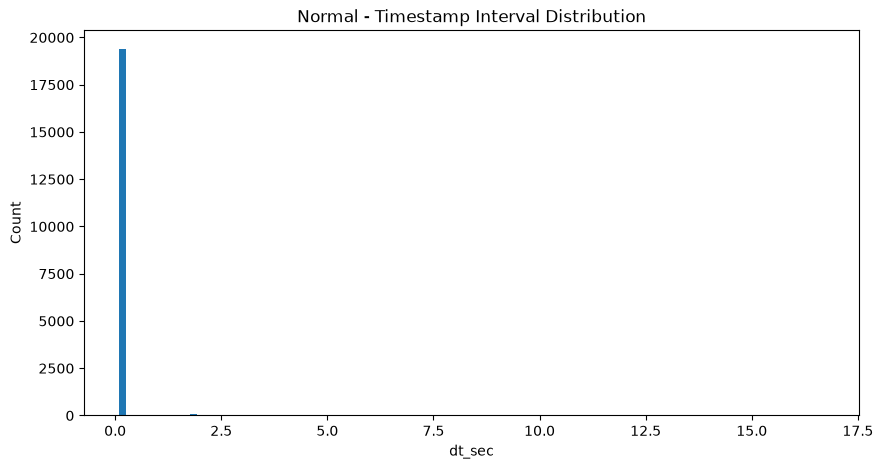

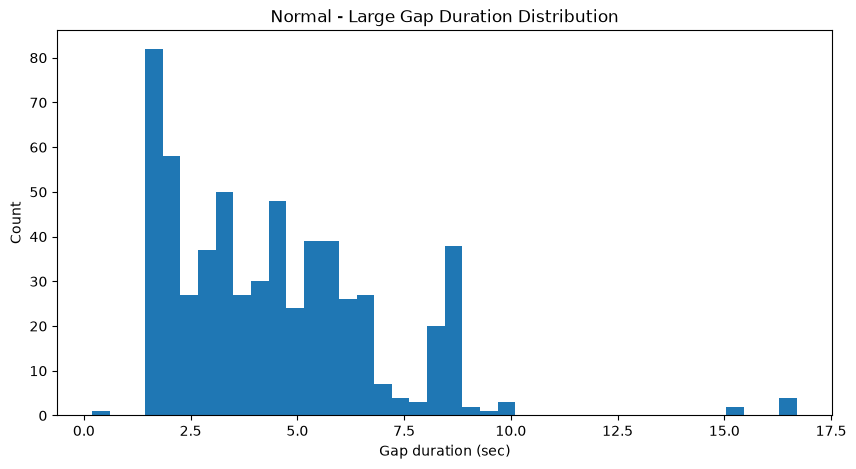

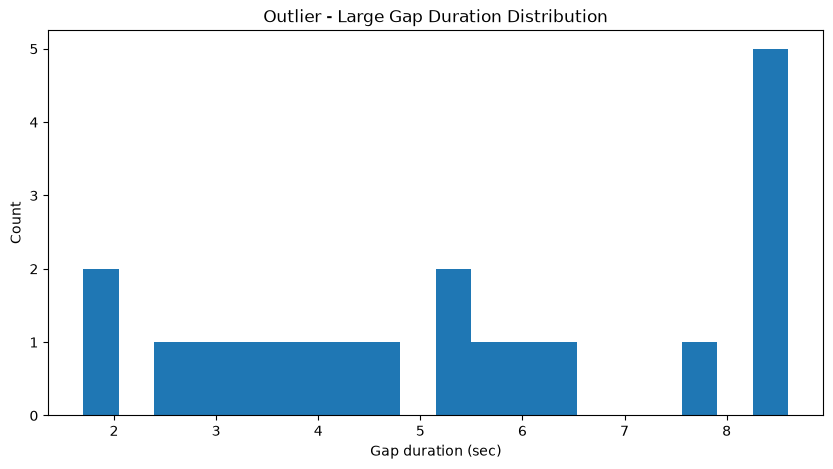

In [23]:
import matplotlib.pyplot as plt

normal_positive_dt = normal.loc[
    normal["dt_sec"] > 0,
    "dt_sec"
]

plt.figure(figsize=(10, 5))
plt.hist(normal_positive_dt, bins=100)
plt.xlabel("dt_sec")
plt.ylabel("Count")
plt.title("Normal - Timestamp Interval Distribution")
plt.show()

# 노말 갭
normal_gap_dt = normal.loc[
    normal["is_large_gap"],
    "dt_sec"
]

plt.figure(figsize=(10, 5))
plt.hist(normal_gap_dt, bins=40)
plt.xlabel("Gap duration (sec)")
plt.ylabel("Count")
plt.title("Normal - Large Gap Duration Distribution")
plt.show()

# 아웃라이어 갭
outlier_gap_dt = outlier.loc[
    outlier["is_large_gap"],
    "dt_sec"
]

plt.figure(figsize=(10, 5))
plt.hist(outlier_gap_dt, bins=20)
plt.xlabel("Gap duration (sec)")
plt.ylabel("Count")
plt.title("Outlier - Large Gap Duration Distribution")
plt.show()

In [24]:
# Q1추가 : 0.15초라는 threshold 때문에 Gap이 생긴 건 아닌가

def threshold_sensitivity(df, name):
    thresholds = [
        0.15,
        0.20,
        0.30,
        0.50,
        1.00,
        2.00,
    ]

    rows = []

    for threshold in thresholds:
        gap_flag = df["dt_sec"] > threshold

        segment_start = (
            df["dt_sec"].isna()
            | df["is_nonincreasing"]
            | gap_flag.fillna(False)
        )

        rows.append({
            "dataset": name,
            "threshold_sec": threshold,
            "gap_count": int(gap_flag.sum()),
            "segments": int(segment_start.sum()),
        })

    return pd.DataFrame(rows)


threshold_table = pd.concat([
    threshold_sensitivity(normal, "normal"),
    threshold_sensitivity(outlier, "outlier"),
])

display(threshold_table)

,dataset,threshold_sec,gap_count,segments
0,normal,0.15,599,602
1,normal,0.20,599,602
2,normal,0.30,598,601
3,normal,0.50,598,601
4,normal,1.00,598,601
5,normal,2.00,476,479
0,outlier,0.15,20,21
1,outlier,0.20,20,21
2,outlier,0.30,20,21
3,outlier,0.50,20,21


In [25]:
# Q2. 특정 row/block 구조가 존재하는가?
# Gap이 랜덤하게 아무 위치에나 발생하는가?
# 아니면 일정한 데이터 block 끝에서 반복되는가?

#① segment 길이 분포
#② gap 발생 row 사이의 거리

In [26]:
def segment_length_summary(df, name):
    sizes = (
        df.groupby("segment_id", sort=False)
        .size()
        .rename("segment_rows")
    )

    return pd.Series({
        "dataset": name,
        "n_segments": len(sizes),

        "min_rows": sizes.min(),
        "median_rows": sizes.median(),
        "q75_rows": sizes.quantile(0.75),
        "max_rows": sizes.max(),

        "segments_eq_50":
            int((sizes == 50).sum()),

        "fraction_eq_50":
            float((sizes == 50).mean()),
    })


segment_summary = pd.DataFrame([
    segment_length_summary(normal, "normal"),
    segment_length_summary(outlier, "outlier"),
])

display(segment_summary)


def segment_length_summary(df, name):
    sizes = (
        df.groupby("segment_id", sort=False)
        .size()
        .rename("segment_rows")
    )

    return pd.Series({
        "dataset": name,
        "n_segments": len(sizes),

        "min_rows": sizes.min(),
        "median_rows": sizes.median(),
        "q75_rows": sizes.quantile(0.75),
        "max_rows": sizes.max(),

        "segments_eq_50":
            int((sizes == 50).sum()),

        "fraction_eq_50":
            float((sizes == 50).mean()),
    })


segment_summary = pd.DataFrame([
    segment_length_summary(normal, "normal"),
    segment_length_summary(outlier, "outlier"),
])

display(segment_summary)


## segment 빈도
normal_segment_sizes = (
    normal.groupby("segment_id")
    .size()
)

print("NORMAL segment length frequency")
display(
    normal_segment_sizes
    .value_counts()
    .sort_index()
    .tail(20)
)

outlier_segment_sizes = (
    outlier.groupby("segment_id")
    .size()
)

print("OUTLIER segment length frequency")
display(
    outlier_segment_sizes
    .value_counts()
    .sort_index()
)

# gap 발생 row간 거리
def gap_row_distance_summary(df, name):
    gap_rows = (
        df.loc[df["is_large_gap"], "source_row"]
        .to_numpy()
    )

    distances = np.diff(gap_rows)

    if len(distances) == 0:
        return pd.Series({
            "dataset": name
        })

    return pd.Series({
        "dataset": name,

        "n_gap_intervals": len(distances),

        "median_row_distance":
            np.median(distances),

        "max_row_distance":
            np.max(distances),

        "distance_eq_50":
            int(np.sum(distances == 50)),

        "fraction_eq_50":
            float(np.mean(distances == 50)),

        "distance_45_to_55":
            int(np.sum(
                (distances >= 45)
                & (distances <= 55)
            )),

        "fraction_45_to_55":
            float(np.mean(
                (distances >= 45)
                & (distances <= 55)
            )),
    })


gap_row_table = pd.DataFrame([
    gap_row_distance_summary(normal, "normal"),
    gap_row_distance_summary(outlier, "outlier"),
])

display(gap_row_table)

# 빈도
normal_gap_rows = normal.loc[
    normal["is_large_gap"],
    "source_row"
].to_numpy()

normal_gap_dist = pd.Series(
    np.diff(normal_gap_rows)
)

display(
    normal_gap_dist
    .value_counts()
    .head(20)
    .rename_axis("row_distance")
    .reset_index(name="count")
)

,dataset,n_segments,min_rows,median_rows,q75_rows,max_rows,segments_eq_50,fraction_eq_50
0,normal,602,1,37.0,50.0,50,202,0.335548
1,outlier,21,3,28.0,47.0,50,5,0.238095


,dataset,n_segments,min_rows,median_rows,q75_rows,max_rows,segments_eq_50,fraction_eq_50
0,normal,602,1,37.0,50.0,50,202,0.335548
1,outlier,21,3,28.0,47.0,50,5,0.238095


NORMAL segment length frequency


31      4
32      9
33      5
34     10
35     10
36     12
37      8
38     13
39      7
40      8
41      5
42     10
43      8
44      9
45      7
46      6
47      3
48      8
49     10
50    202
Name: count, dtype: int64

OUTLIER segment length frequency


3     1
4     2
8     1
10    1
15    2
18    1
24    1
25    1
28    1
31    1
36    1
40    1
42    1
47    1
50    5
Name: count, dtype: int64

,dataset,n_gap_intervals,median_row_distance,max_row_distance,distance_eq_50,fraction_eq_50,distance_45_to_55,fraction_45_to_55
0,normal,598,37.0,50,202,0.337793,236,0.394649
1,outlier,19,31.0,50,5,0.263158,6,0.315789


,row_distance,count
0,50,202
1,13,13
2,38,13
3,36,12
4,22,12
5,8,12
6,24,11
7,23,11
8,12,11
9,26,10


In [27]:
# 50행 block 가능성 확인
normal_gap_position = normal.loc[
    normal["is_large_gap"],
    ["source_row", "dt_sec"]
].copy()

normal_gap_position["row_mod_50"] = (
    normal_gap_position["source_row"] % 50
)

display(
    normal_gap_position["row_mod_50"]
    .value_counts()
    .sort_index()
    .rename_axis("source_row % 50")
    .reset_index(name="count")
)

,source_row % 50,count
0,0,14
1,1,7
2,2,14
3,3,13
4,4,8
5,5,8
6,6,11
7,7,30
8,8,8
9,9,3


In [28]:
# Q3. Segment boundary 유지 여부
## 모름 : gap 원인
## 암 : gap 사이에는 관측값이 없다